# 04 - Model Evaluation

This notebook evaluates the trained autoencoder using modular functions from `evaluate.py`.

## Main goals:
1. Load the trained model
2. Calculate reconstruction errors
3. Find optimal threshold
4. Calculate performance metrics
5. Visualize results
6. Analyze performance

## 0 - Imports and configuration

In [1]:
#Imports
import sys
sys.path.append('../src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

from preprocessing import load_preprocessed_data
from train import create_dataloaders
from evaluate import load_model, calculate_errors, calculate_metrics, plot_confusion_matrix, plot_error_distributions, plot_roc_curve

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1 - Load data and model

In [2]:
#Preprocessed data
data = load_preprocessed_data('../data/processed')

X_val, X_test, y_val, y_test = data['X_val'], data['X_test'], data['y_val'], data['y_test']

print(f"Val : {X_val.shape}")
print(f"Test : {X_test.shape}")

input_dim = X_val.shape[1]

Val : (12075, 33)
Test : (82391, 33)


In [3]:
#DataLoaders
batch_size = 256
_, val_loader, test_loader = create_dataloaders(
    np.zeros((1, input_dim)),  
    X_val,
    X_test,
    batch_size = batch_size
)

DataLoaders created:
Batch size : 256
Train batches : 1
Val batches : 48
Test batches : 322


In [4]:
#Trained model
model_path = '../models/autoencoder.pth'
latent_dim = 8

model, device = load_model(
    model_path = model_path,
    input_dim = input_dim,
    latent_dim = latent_dim,
    device = None
)

## 2 - Calculate reconstruction errors

In [5]:
#Errors
val_errors, test_errors = calculate_errors(
    model = model,
    val_loader = val_loader,
    test_loader = test_loader,
    device = device
)

#Label separation
val_normal_errors = val_errors[y_val == 0]
val_attack_errors = val_errors[y_val == 1]
test_normal_errors = test_errors[y_test == 0]
test_attack_errors = test_errors[y_test == 1]

print("Error stats :")
print(f"Val Normal :  {val_normal_errors.mean():.6f}")
if len(val_attack_errors) > 0:
    print(f"Val Attack :  {val_attack_errors.mean():.6f}")
    print(f"Ratio : {val_attack_errors.mean() / val_normal_errors.mean():.2f}x")
else:
    print("Val Attack :  N/A (validation set contains only normal traffic, as expected)")

Error stats :
Val Normal :  0.011496
Val Attack :  N/A (validation set contains only normal traffic, as expected)


## 3 - Find optimal threshold

In [6]:
#Optimal threshold

optimal_threshold = 0.003722

## 4 - Calculate performance metrics

In [7]:
#Predict
y_pred = (test_errors > optimal_threshold).astype(int)

#Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1:.4f}")
print(f"\nTN : {tn:6d} | FP : {fp:6d}")
print(f"FN: {fn:6d} | TP : {tp:6d}")


#Metrics
metrics = calculate_metrics(
    y_test = y_test,
    test_errors = test_errors,
    threshold = optimal_threshold
)


Accuracy : 0.7497 (74.97%)
Precision : 0.9054 (90.54%)
Recall : 0.7693 (76.93%)
F1-Score : 0.8318

TN :  10772 | FP :   5330
FN:  15291 | TP :  50998
Test set performance :
Threshold: 0.003722
Accuracy: 0.7497 (74.97%)
Precision : 0.9054 (90.54%)
Recall : 0.7693 (76.93%)
F1-Score : 0.8318
ROC-AUC : 0.7961


## 5 - Confusion matrix

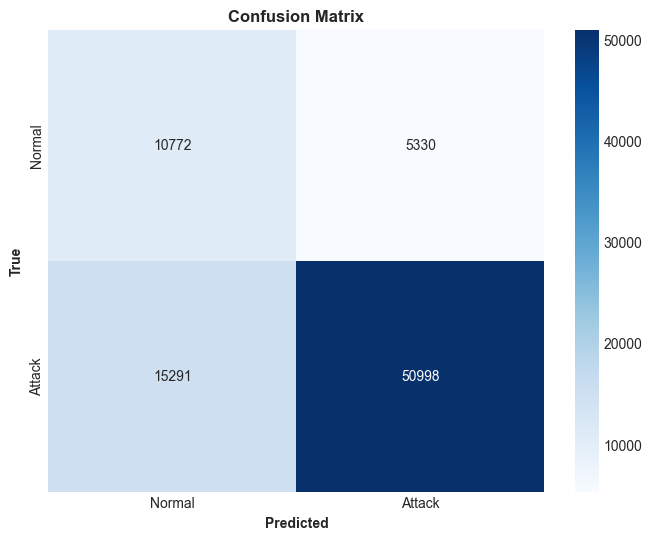

In [8]:
#Confusion matrix
plot_confusion_matrix(cm, save_path = '../results/figures/confusion_matrix.png')

## 6 - ROC Curve

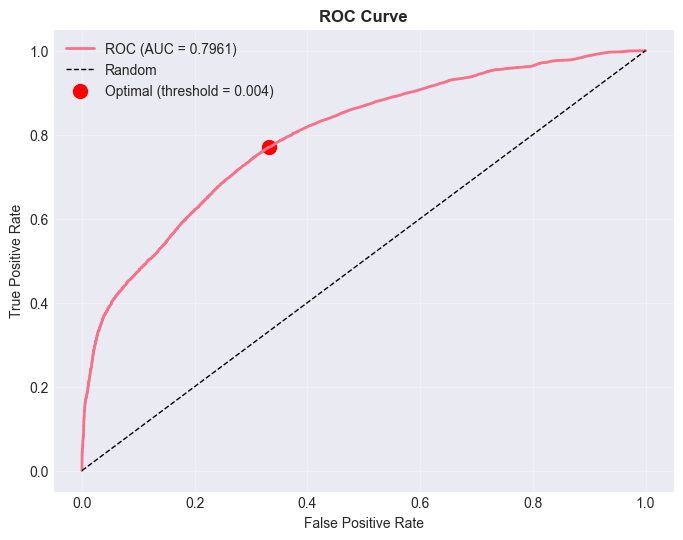

In [9]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, test_errors)
roc_auc = roc_auc_score(y_test, test_errors)

#Find optimal point (closest to threshold)
optimal_idx = np.argmin(np.abs(thresholds - optimal_threshold))

plot_roc_curve(fpr, tpr, roc_auc, optimal_idx, optimal_threshold,
               save_path = '../results/figures/roc_curve.png')

## 7 - Error distributions

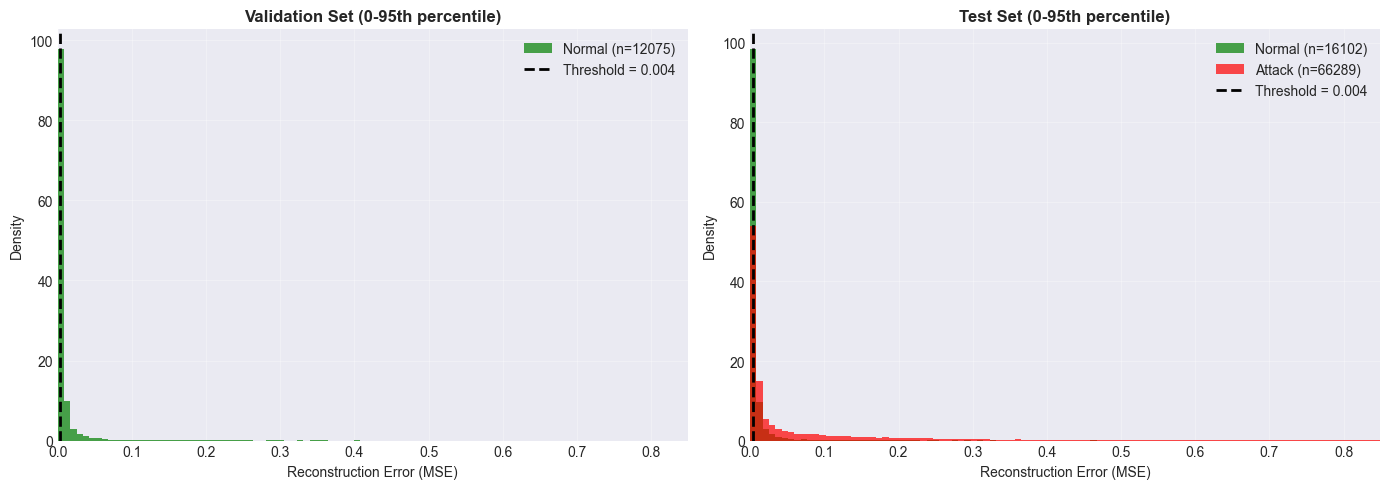

Error statistics (within 95th percentile) :

Normal errors :
Median : 0.0025
95th percentile : 0.0297

Attack errors :
Median : 0.0119
95th percentile : 1.2630

Separation (median) : 4.81x


In [10]:
#Calculate 95th percentile for zoom
xlim_95 = np.percentile(test_errors, 95)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

#Validation set
axes[0].hist(val_normal_errors, bins = 100, alpha = 0.7, 
            label = f'Normal (n={len(val_normal_errors)})', 
            color = 'green', density = True, range = (0, xlim_95))
if len(val_attack_errors) > 0:
    axes[0].hist(val_attack_errors, bins = 100, alpha = 0.7, 
            label = 'Attack', color = 'red', 
            density = True, range = (0, xlim_95))
axes[0].axvline(optimal_threshold, color = 'black', linestyle = '--', 
            linewidth = 2, label = f'Threshold = {optimal_threshold :.3f}')
axes[0].set_xlim(0, xlim_95)
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Validation Set (0-95th percentile)', fontweight = 'bold')
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

#Test set
axes[1].hist(test_normal_errors, bins = 100, alpha = 0.7, 
            label = f'Normal (n={len(test_normal_errors)})', 
            color = 'green', density = True, range = (0, xlim_95))
axes[1].hist(test_attack_errors, bins = 100, alpha = 0.7, 
            label = f'Attack (n={len(test_attack_errors)})', 
            color = 'red', density = True, range = (0, xlim_95))
axes[1].axvline(optimal_threshold, color = 'black', linestyle = '--', 
            linewidth = 2, label = f'Threshold = {optimal_threshold :.3f}')
axes[1].set_xlim(0, xlim_95)
axes[1].set_xlabel('Reconstruction Error (MSE)')
axes[1].set_ylabel('Density')
axes[1].set_title('Test Set (0-95th percentile)', fontweight = 'bold')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig('../results/figures/error_distributions.png', dpi = 300, bbox_inches = 'tight')
plt.show()

print("Error statistics (within 95th percentile) :")
print(f"\nNormal errors :")
print(f"Median : {np.median(test_normal_errors) :.4f}")
print(f"95th percentile : {np.percentile(test_normal_errors, 95) :.4f}")

print(f"\nAttack errors :")
print(f"Median : {np.median(test_attack_errors) :.4f}")
print(f"95th percentile : {np.percentile(test_attack_errors, 95) :.4f}")

print(f"\nSeparation (median) : {np.median(test_attack_errors) / np.median(test_normal_errors) :.2f}x")

## 8 - Detailed analysis

In [11]:
print("Performance analysis")

print("\n1. Classification metrics :")
print(f"Accuracy : {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"Precision : {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
print(f"Recall : {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
print(f"F1-Score : {metrics['f1_score']:.4f}")
print(f"ROC-AUC : {metrics['roc_auc']:.4f}")

print("\n2. Reconstruction errors :")
print(f"Normal | Mean : {test_normal_errors.mean():.6f}")
print(f"Attack | Mean : {test_attack_errors.mean():.6f}")
print(f"Separation : {test_attack_errors.mean() / test_normal_errors.mean():.2f}x")

print(f"\n3. Threshold :")
print(f"Optimal threshold : {optimal_threshold:.6f}")

print("\n4. Confusion matrix :")
print(f"TN : {tn:6d} | FP : {fp:6d}")
print(f"FN : {fn:6d} | TP : {tp:6d}")

fpr_rate = fp / (fp + tn)
fnr_rate = fn / (fn + tp)
print("\n5. Error Rates:")
print(f"FPR : {fpr_rate:.4f} ({fpr_rate*100:.2f}%)")
print(f"FNR : {fnr_rate:.4f} ({fnr_rate*100:.2f}%)")

Performance analysis

1. Classification metrics :
Accuracy : 0.7497 (74.97%)
Precision : 0.9054 (90.54%)
Recall : 0.7693 (76.93%)
F1-Score : 0.8318
ROC-AUC : 0.7961

2. Reconstruction errors :
Normal | Mean : 0.013145
Attack | Mean : 8.886042
Separation : 676.00x

3. Threshold :
Optimal threshold : 0.003722

4. Confusion matrix :
TN :  10772 | FP :   5330
FN :  15291 | TP :  50998

5. Error Rates:
FPR : 0.3310 (33.10%)
FNR : 0.2307 (23.07%)


## 9 - Results

In [12]:
#Create summary DataFrame
summary_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
        'Threshold', 'Separation Ratio',
        'True Negatives', 'False Positives', 'False Negatives', 'True Positives'
    ],
    'Value': [
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1_score']:.4f}",
        f"{metrics['roc_auc']:.4f}",
        f"{optimal_threshold:.6f}",
        f"{test_attack_errors.mean() / test_normal_errors.mean():.2f}x",
        str(tn), str(fp), str(fn), str(tp)
    ]
})

print("Results")
print(summary_df.to_string(index = False))

Results
          Metric    Value
        Accuracy   0.7497
       Precision   0.9054
          Recall   0.7693
        F1-Score   0.8318
         ROC-AUC   0.7961
       Threshold 0.003722
Separation Ratio  676.00x
  True Negatives    10772
 False Positives     5330
 False Negatives    15291
  True Positives    50998
